# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



## Target Popularity
Could be streams, followers, plays or views.

## Column sort

### y candidates (post-release outcomes)
1. Popularity
2.  Number of Times Charted
3.	Streams
4.  Highest Charting Position
5.  Weeks Charted
### X (pre-release predictors)
1.   Artist  drop this column wont get clean distribution
2.   Artist Followers  is a better predictor of popularity
3.   Genre
4.   Release Date
5.   Danceability
6.	Energy
7.	Loudness
8.	Speechiness
9. Acousticness
10.  Liveness
11.  Tempo
12.  Duration (ms)
13.  Valence
14.  Chord
### Drop (IDs, redundant, or otherwise unusable)
1. Index is row number
2. Song Name is unique
3. Song Id is unique
4. Week of Highest Charting


In [116]:
# Set the URL
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [117]:
# Look at the headers
!curl -s -I {url}


HTTP/1.1 200 OK
x-amz-id-2: 8+3IezHZr7x/z2Dvx2Rv+QTo4MzKH0LWRkNPlgpTyfrpu1Xim67baoVkWzNGA2NwLv854ruBqQjA0JuNaNfdMPF7NfY983Vy
x-amz-request-id: 640TYSYJZ1RBH2PC
Date: Wed, 15 Jul 2026 03:01:57 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [118]:
# Download the file
!curl -s -O {url}


In [119]:
# Verify
!ls -la


total 740
drwxr-xr-x 1 root root   4096 Jul 15 01:41 .
drwxr-xr-x 1 root root   4096 Jul 15 01:38 ..
drwxr-xr-x 4 root root   4096 Jun  4 13:32 .config
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 738124 Jul 15 03:02 Spotify.csv


In [120]:
# Look at the field names
!head -1 Spotify.csv | tr , '\n' | cat -n


     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


## IMPORT Libraries

In [121]:
# Load and inspect data
import pandas as pd
import numpy as np


Create Dataframe df

In [122]:

df = pd.read_csv('Spotify.csv')

# Quick inspection

print(df.head())



   Index  Highest Charting Position  Number of Times Charted  \
0      1                          1                        8   
1      2                          2                        3   
2      3                          1                       11   
3      4                          3                        5   
4      5                          5                        1   

  Week of Highest Charting                          Song Name     Streams  \
0   2021-07-23--2021-07-30                            Beggin'  48,633,449   
1   2021-07-23--2021-07-30          STAY (with Justin Bieber)  47,248,719   
2   2021-06-25--2021-07-02                           good 4 u  40,162,559   
3   2021-07-02--2021-07-09                         Bad Habits  37,799,456   
4   2021-07-23--2021-07-30  INDUSTRY BABY (feat. Jack Harlow)  33,948,454   

           Artist Artist Followers                 Song ID  \
0        Måneskin          3377762  3Wrjm47oTz2sjIgck11l5e   
1   The Kid LAROI          2

In [123]:

print(df.describe())

             Index  Highest Charting Position  Number of Times Charted
count  1556.000000                1556.000000              1556.000000
mean    778.500000                  87.744216                10.668380
std     449.322824                  58.147225                16.360546
min       1.000000                   1.000000                 1.000000
25%     389.750000                  37.000000                 1.000000
50%     778.500000                  80.000000                 4.000000
75%    1167.250000                 137.000000                12.000000
max    1556.000000                 200.000000               142.000000


In [124]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

In [125]:
# Check for missing values
print(df.isnull().sum())



Index                        0
Highest Charting Position    0
Number of Times Charted      0
Week of Highest Charting     0
Song Name                    0
Streams                      0
Artist                       0
Artist Followers             0
Song ID                      0
Genre                        0
Release Date                 0
Weeks Charted                0
Popularity                   0
Danceability                 0
Energy                       0
Loudness                     0
Speechiness                  0
Acousticness                 0
Liveness                     0
Tempo                        0
Duration (ms)                0
Valence                      0
Chord                        0
dtype: int64


In [126]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Potential target columns:", numerical_cols)

Potential target columns: ['Index', 'Highest Charting Position', 'Number of Times Charted']


In [127]:
print(df['Streams'].head(10))
print("\nDtype:", df['Streams'].dtype)

0    48,633,449
1    47,248,719
2    40,162,559
3    37,799,456
4    33,948,454
5    30,071,134
6    29,356,736
7    26,951,613
8    25,030,128
9    24,551,591
Name: Streams, dtype: object

Dtype: object


In [128]:
# Strip commas, convert to ints
df['Streams'] = df['Streams'].str.replace(',', '', regex=False).astype(int)

# Verifying the commas are stripped from the dataset
print("Dtype after clean:", df['Streams'].dtype)  # Streams no missing streams 1556 non-null   object
print(df['Streams'].describe())                   # min 4.18 million streams, median 5.28 million streams, max is 48.64 streams,
                                                  # mean is greater 6.34 > than the median so data is right skewed

Dtype after clean: int64
count    1.556000e+03
mean     6.340219e+06
std      3.369479e+06
min      4.176083e+06
25%      4.915322e+06
50%      5.275748e+06
75%      6.455044e+06
max      4.863345e+07
Name: Streams, dtype: float64


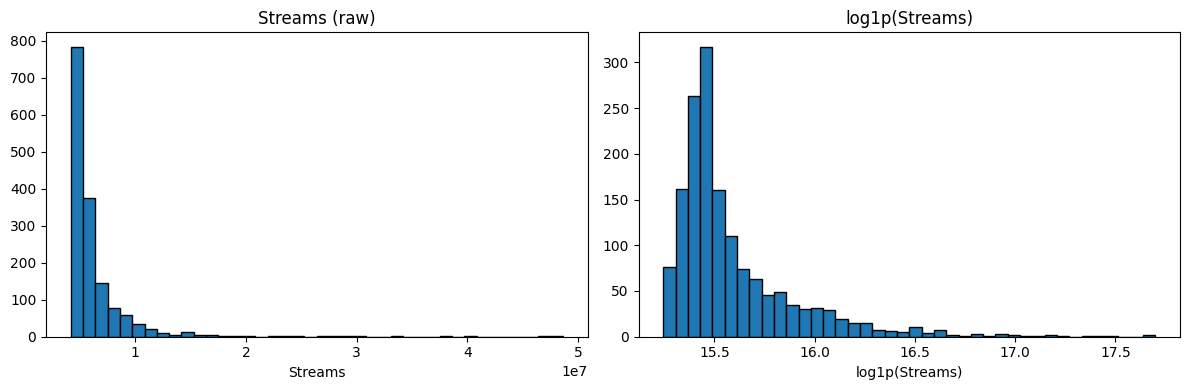

Skewness (raw):   5.915
Skewness (log1p): 2.388


In [129]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw Streams
axes[0].hist(df['Streams'], bins=40, edgecolor='black')
axes[0].set_title('Streams (raw)')
axes[0].set_xlabel('Streams')

# log1p(Streams)
axes[1].hist(np.log1p(df['Streams']), bins=40, edgecolor='black')
axes[1].set_title('log1p(Streams)')
axes[1].set_xlabel('log1p(Streams)')

plt.tight_layout()
plt.show()

# Quantify skewness
from scipy.stats import skew
print(f"Skewness (raw):   {skew(df['Streams']):.3f}")
print(f"Skewness (log1p): {skew(np.log1p(df['Streams'])):.3f}")

## Target us y = log1p (Streams)

In [130]:
y = np.log1p(df['Streams'])
print(f"y (log1p Streams) — mean: {y.mean():.2f}, std: {y.std():.2f}")

y (log1p Streams) — mean: 15.60, std: 0.32


### Number of times charted

In [131]:
print(df['Number of Times Charted'].head(10))
print("\nDtype:", df['Number of Times Charted'].dtype)

0     8
1     3
2    11
3     5
4     1
5    18
6    16
7    10
8     8
9    10
Name: Number of Times Charted, dtype: int64

Dtype: int64


### Highest charing position

In [132]:
print(df['Highest Charting Position'].head(10))
print("\nDtype:", df['Highest Charting Position'].dtype)

0    1
1    2
2    1
3    3
4    5
5    1
6    3
7    2
8    3
9    8
Name: Highest Charting Position, dtype: int64

Dtype: int64


### Note: Weeks Charted date-to-int exploration

Expolring the 'Weeks Charted' data ranges and turned to ints - dropped from y in favor of 'Number of Times Charted' values were already ints and pottentially might better for modeling.

In [133]:
print(df['Weeks Charted'].head(10))
print("\nDtype:", df['Weeks Charted'].dtype)

0    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
1    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
2    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
3    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
4                               2021-07-23--2021-07-30
5    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
6    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
7    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
8    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
9    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
Name: Weeks Charted, dtype: object

Dtype: object


In [135]:
print(df.to_dict(orient='list'))
# Output: {'Weeks Charted': [Timestamp('2021-07-23 00:00:00'), Timestamp('2021-07-30 00:00:00')], 'Weeks Charted_Int':}

# Output just the new integers as a standard Python list
int_list = df['Weeks Charted'].tolist()
print(int_list)

{'Index': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 22

In [154]:


# 1. Create a larger list of dates
large_date_list = ['2021-07-23', '2021-07-30', '2021-08-06', '2021-08-13', '2021-08-20', '2021-08-27']
check_df = pd.DataFrame({'Weeks Charted': pd.to_datetime(large_date_list)})

# 2. Convert the entire column instantly
check_df['Weeks Charted_Int'] = df['Weeks Charted'].dt.strftime('%Y%m%d').astype(int)

# 3. View just the first 5 rows
print(df.head(120))


AttributeError: Can only use .dt accessor with datetimelike values

### Popularity

May use these code cells

In [137]:
print(df['Popularity'].head(10))
print("\nDtype:", df['Popularity'].dtype)

0    100
1     99
2     99
3     98
4     96
5     97
6     94
7     95
8     96
9     95
Name: Popularity, dtype: object

Dtype: object


In [138]:
# Examine potential targets
potential_targets = ['Popularity'] + [col for col in df.columns
  if any(word in col.lower()
  for word in ['stream', 'view', 'play', 'rank', 'chart'])]

TypeError: unsupported operand type(s) for -: 'str' and 'str'

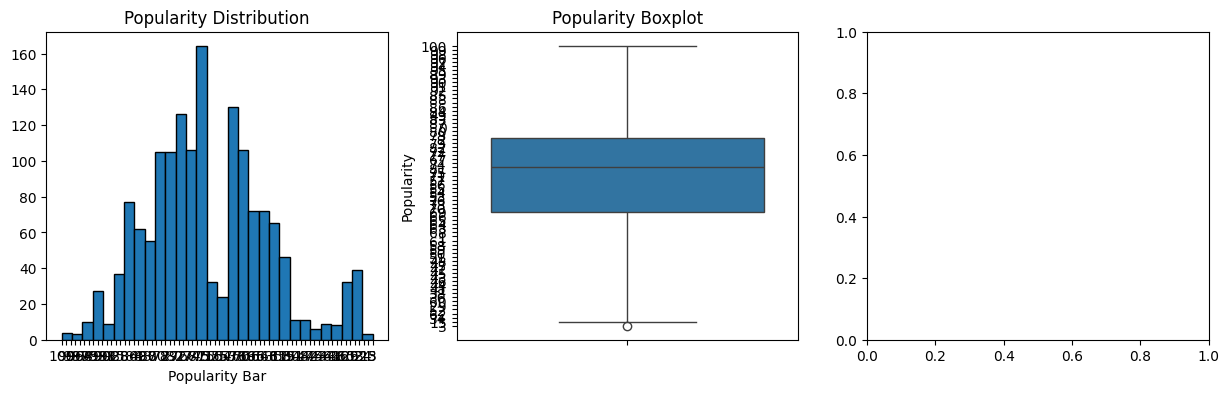

In [140]:

import seaborn as sns

# Check distribution of 'Popularity'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['Popularity'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Popularity Distribution')
axes[0].set_xlabel('Popularity Bar')

# Boxplot
sns.boxplot(y=df['Popularity'], ax=axes[1])
axes[1].set_title('Popularity Boxplot')

# Check for outliers using IQR
Q1 = df['Popularity'].quantile(0.25)
Q3 = df['Popularity'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Popularity'] < Q1 - 1.5*IQR) | (df['Popularity'] > Q3 + 1.5*IQR)]
print(f"Number of outlier songs: {len(outliers)}")

### Checking why IQR wont print above

In [143]:
# What's non-numeric in Popularity?
non_numeric = df[pd.to_numeric(df['Popularity'], errors='coerce').isna()]
print(f"Rows with non-numeric Popularity: {len(non_numeric)}")
print(non_numeric['Popularity'].value_counts())

Rows with non-numeric Popularity: 11
Popularity
    11
Name: count, dtype: int64


In [144]:
df['Popularity'] = pd.to_numeric(df['Popularity'], errors='coerce')
print(df['Popularity'].dtype, df['Popularity'].isna().sum(), "nulls")

float64 11 nulls


Number of outlier songs: 60


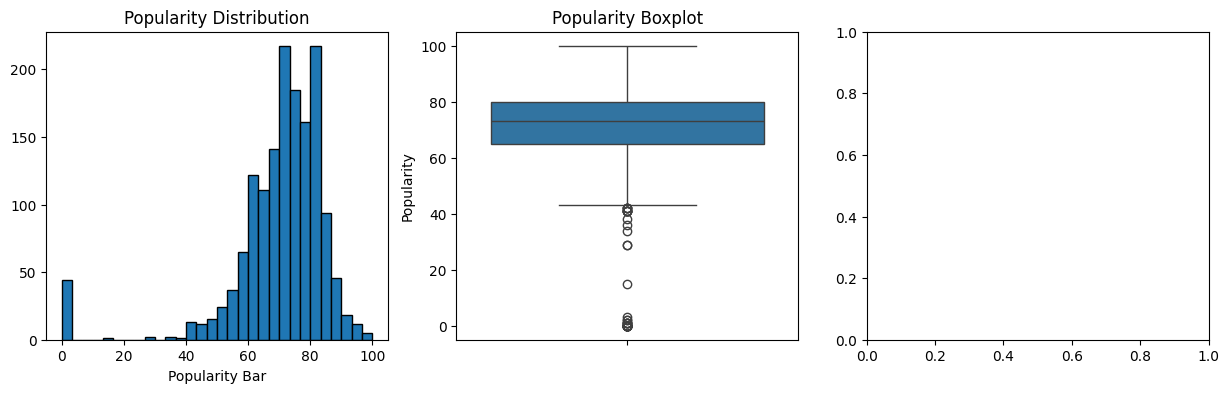

In [149]:
# Check distribution of 'Popularity'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['Popularity'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Popularity Distribution')
axes[0].set_xlabel('Popularity Bar')

# Boxplot
sns.boxplot(y=df['Popularity'], ax=axes[1])
axes[1].set_title('Popularity Boxplot')

# Check for outliers using IQR
Q1 = df['Popularity'].quantile(0.25)
Q3 = df['Popularity'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Popularity'] < Q1 - 1.5*IQR) | (df['Popularity'] > Q3 + 1.5*IQR)]
print(f"Number of outlier songs: {len(outliers)}")

In [155]:
# DESCRIBE
print(df['Popularity'].describe())

count    1545.000000
mean       70.089320
std        15.824034
min         0.000000
25%        65.000000
50%        73.000000
75%        80.000000
max       100.000000
Name: Popularity, dtype: float64


In [141]:
print(df.shape)
print(df.columns.tolist())

(1556, 23)
['Index', 'Highest Charting Position', 'Number of Times Charted', 'Week of Highest Charting', 'Song Name', 'Streams', 'Artist', 'Artist Followers', 'Song ID', 'Genre', 'Release Date', 'Weeks Charted', 'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Chord']


In [142]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   int64 
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

### Drop X COULUMNS

In [150]:
drop_cols = ['Index', 'Song Name', 'Song ID', 'Week of Highest Charting',
             'Weeks Charted', 'Artist', 'Highest Charting Position',
             'Number of Times Charted', 'Streams', 'Popularity']
X = df.drop(columns=drop_cols)
print(X.shape)
print(X.columns.tolist())

(1556, 13)
['Artist Followers', 'Genre', 'Release Date', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Chord']


In [157]:
print(X.shape)
print(X.dtypes)

(1556, 13)
Artist Followers    object
Genre               object
Release Date        object
Danceability        object
Energy              object
Loudness            object
Speechiness         object
Acousticness        object
Liveness            object
Tempo               object
Duration (ms)       object
Valence             object
Chord               object
dtype: object


In [158]:
#Checking for non numeric values

for col in X.columns:
    n_bad = pd.to_numeric(X[col], errors='coerce').isna().sum()
    print(f"{col:20s}  non-numeric rows: {n_bad}")

Artist Followers      non-numeric rows: 11
Genre                 non-numeric rows: 1556
Release Date          non-numeric rows: 1541
Danceability          non-numeric rows: 11
Energy                non-numeric rows: 11
Loudness              non-numeric rows: 11
Speechiness           non-numeric rows: 11
Acousticness          non-numeric rows: 11
Liveness              non-numeric rows: 11
Tempo                 non-numeric rows: 11
Duration (ms)         non-numeric rows: 11
Valence               non-numeric rows: 11
Chord                 non-numeric rows: 1556


In [160]:
audio_cols = ['Artist Followers', 'Danceability', 'Energy', 'Loudness',
                 'Speechiness', 'Acousticness', 'Liveness', 'Tempo',
                 'Duration (ms)', 'Valence']
for col in audio_cols:
   X[col] = pd.to_numeric(X[col], errors='coerce')

bad_rows_mask = X[audio_cols].isna().any(axis=1)
print(f"Rows with any NaN in audio features: {bad_rows_mask.sum()}")
print(X[bad_rows_mask].head(15))

Rows with any NaN in audio features: 11
      Artist Followers Genre Release Date  Danceability  Energy  Loudness  \
35                 NaN                              NaN     NaN       NaN   
163                NaN                              NaN     NaN       NaN   
464                NaN                              NaN     NaN       NaN   
530                NaN                              NaN     NaN       NaN   
636                NaN                              NaN     NaN       NaN   
654                NaN                              NaN     NaN       NaN   
750                NaN                              NaN     NaN       NaN   
784                NaN                              NaN     NaN       NaN   
876                NaN                              NaN     NaN       NaN   
1140               NaN                              NaN     NaN       NaN   
1538               NaN                              NaN     NaN       NaN   

      Speechiness  Acousticness  Li

### Genre

In [161]:
print(df['Genre'].head(10).tolist())

["['indie rock italiano', 'italian pop']", "['australian hip hop']", "['pop']", "['pop', 'uk pop']", "['lgbtq+ hip hop', 'pop rap']", "['lgbtq+ hip hop', 'pop rap']", "['dance pop', 'pop']", "['puerto rican pop', 'trap latino']", "['latin', 'reggaeton', 'trap latino']", "['indie rock italiano', 'italian pop']"]


In [162]:
### Release dates
print(df['Release Date'].head(10).tolist())
print("15 numeric ones:")
print(df[pd.to_numeric(df['Release Date'], errors='coerce').notna()]['Release Date'].tolist())

['2017-12-08', '2021-07-09', '2021-05-21', '2021-06-25', '2021-07-23', '2021-03-31', '2021-04-09', '2021-05-20', '2021-06-04', '2021-03-19']
15 numeric ones:
['2014', '1995', '2015', '1995', '1963', '1962', '1963', '2002', '1990', '1981', '1994', '2012', '1981', '2016', '2016']


In [163]:
# Dropping rows that are empty NaN
audio_cols = ['Artist Followers', 'Danceability', 'Energy', 'Loudness',
              'Speechiness', 'Acousticness', 'Liveness', 'Tempo',
              'Duration (ms)', 'Valence']

bad_rows_mask = X[audio_cols].isna().any(axis=1)
X = X[~bad_rows_mask].copy()
y = y[~bad_rows_mask].copy()   # keep X and y aligned

print(f"X shape after dropping empty rows: {X.shape}")
print(f"y shape: {y.shape}")

X shape after dropping empty rows: (1545, 13)
y shape: (1545,)


In [164]:
# Pad year-only entries to full dates, then parse
X['Release Date'] = X['Release Date'].astype(str)
year_only_mask = X['Release Date'].str.match(r'^\d{4}$')
X.loc[year_only_mask, 'Release Date'] = X.loc[year_only_mask, 'Release Date'] + '-01-01'

X['release_year'] = pd.to_datetime(X['Release Date'], errors='coerce').dt.year
X = X.drop(columns=['Release Date'])

print(X['release_year'].describe())
print(f"Nulls in release_year: {X['release_year'].isna().sum()}")

count    1543.00000
mean     2018.46792
std         7.48826
min      1942.00000
25%      2020.00000
50%      2020.00000
75%      2021.00000
max      2021.00000
Name: release_year, dtype: float64
Nulls in release_year: 2


### Checking Null
Nulls in release date

In [166]:
print(X[X['release_year'].isna()])

     Artist Followers                                            Genre  \
681         4953667.0  ['adult standards', 'easy listening', 'lounge']   
682         4953667.0  ['adult standards', 'easy listening', 'lounge']   

     Danceability  Energy  Loudness  Speechiness  Acousticness  Liveness  \
681         0.607   0.103   -14.405       0.0404         0.804    0.0760   
682         0.512   0.339   -13.119       0.0498         0.727    0.0977   

       Tempo  Duration (ms)  Valence  Chord  release_year  
681  110.378       136427.0    0.341      A           NaN  
682  174.609       120693.0    0.951  G#/Ab           NaN  


In [167]:
print(df.loc[[681, 682], 'Release Date'].tolist())

['1957-09', '1957-09']


In [168]:
# Handle the 2 stragglers: pad YYYY-MM to YYYY-MM-01
still_null = X['release_year'].isna()
raw_dates = df.loc[X[still_null].index, 'Release Date']

# For each null row, if it's YYYY-MM, extract the year directly
X.loc[still_null, 'release_year'] = raw_dates.str.extract(r'^(\d{4})')[0].astype(float)

print(f"Nulls in release_year now: {X['release_year'].isna().sum()}")
print(X.loc[[681, 682], 'release_year'])

Nulls in release_year now: 0
681    1957.0
682    1957.0
Name: release_year, dtype: float64


In [169]:
# Genre — how many unique tags total?
import ast

# Parse the stringified lists into real Python lists
X['Genre_parsed'] = X['Genre'].apply(ast.literal_eval)

# Flatten and count
from collections import Counter
all_genres = [g for sublist in X['Genre_parsed'] for g in sublist]
genre_counts = Counter(all_genres)

print(f"Total unique genres: {len(genre_counts)}")
print(f"\nTop 20 genres by frequency:")
for genre, count in genre_counts.most_common(20):
    print(f"  {count:5d}  {genre}")

# Chord — smaller, just show all
print(f"\n\nChord unique values: {X['Chord'].nunique()}")
print(X['Chord'].value_counts())

Total unique genres: 334

Top 20 genres by frequency:
    485  pop
    310  rap
    257  dance pop
    256  post-teen pop
    164  pop rap
    159  trap
    157  reggaeton
    155  trap latino
    154  latin
    151  hip hop
    124  melodic rap
     85  canadian pop
     60  electropop
     54  pop dance
     53  german hip hop
     53  atl hip hop
     52  uk pop
     50  edm
     47  chicago rap
     45  reggaeton colombiano


Chord unique values: 12
Chord
C#/Db    214
C        155
B        141
G        136
F        131
G#/Ab    130
D        125
A#/Bb    122
F#/Gb    121
A        118
E        112
D#/Eb     40
Name: count, dtype: int64


In [170]:
# --- Genre encoding ---

# Keep only the top 15 genre tags
TOP_N = 15
top_genres = [g for g, _ in genre_counts.most_common(TOP_N)]
print(f"Top {TOP_N} genres kept: {top_genres}")

# Multi-hot columns
for g in top_genres:
    col_name = f'genre_{g.replace(" ", "_")}'
    X[col_name] = X['Genre_parsed'].apply(lambda tags: int(g in tags))

# Count of genre tags per song
X['n_genres'] = X['Genre_parsed'].apply(len)

# Drop the raw text columns
X = X.drop(columns=['Genre', 'Genre_parsed'])

# --- Chord encoding ---
chord_dummies = pd.get_dummies(X['Chord'], prefix='chord', dtype=int)
X = pd.concat([X.drop(columns=['Chord']), chord_dummies], axis=1)

print(f"\nX shape after encoding: {X.shape}")
print(f"Columns: {X.columns.tolist()}")

Top 15 genres kept: ['pop', 'rap', 'dance pop', 'post-teen pop', 'pop rap', 'trap', 'reggaeton', 'trap latino', 'latin', 'hip hop', 'melodic rap', 'canadian pop', 'electropop', 'pop dance', 'german hip hop']

X shape after encoding: (1545, 39)
Columns: ['Artist Followers', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'release_year', 'genre_pop', 'genre_rap', 'genre_dance_pop', 'genre_post-teen_pop', 'genre_pop_rap', 'genre_trap', 'genre_reggaeton', 'genre_trap_latino', 'genre_latin', 'genre_hip_hop', 'genre_melodic_rap', 'genre_canadian_pop', 'genre_electropop', 'genre_pop_dance', 'genre_german_hip_hop', 'n_genres', 'chord_A', 'chord_A#/Bb', 'chord_B', 'chord_C', 'chord_C#/Db', 'chord_D', 'chord_D#/Eb', 'chord_E', 'chord_F', 'chord_F#/Gb', 'chord_G', 'chord_G#/Ab']


## Train/test split



In [171]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (1236, 39), y_train: (1236,)
X_test:  (309, 39), y_test:  (309,)


In [172]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Dummy: always predicts the mean of y_train
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))

print(f"Dummy RMSE (log1p Streams units): {rmse_dummy:.4f}")

Dummy RMSE (log1p Streams units): 0.2914


### Random Forest

In [173]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Dummy RMSE:         0.2914")
print(f"Improvement:        {(1 - rmse_rf/0.2914)*100:.1f}%")

Random Forest RMSE: 0.2883
Dummy RMSE:         0.2914
Improvement:        1.1%


In [174]:


# Feature importances from the RF we just trained
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))
print(f"\nTop 5 features account for {importances.head(5).sum()*100:.1f}% of importance")

Artist Followers    0.138403
release_year        0.098308
Acousticness        0.083184
Tempo               0.082166
Liveness            0.080588
Loudness            0.078031
Duration (ms)       0.070747
Valence             0.067156
Speechiness         0.059934
Energy              0.055823
Danceability        0.046333
n_genres            0.016165
chord_G#/Ab         0.011582
chord_D#/Eb         0.008543
genre_reggaeton     0.008467
dtype: float64

Top 5 features account for 48.3% of importance


In [175]:
y_pred_train = rf.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test RMSE:  {rmse_rf:.4f}")
print(f"Ratio (train/test): {rmse_train/rmse_rf:.3f}")

Train RMSE: 0.1178
Test RMSE:  0.2883
Ratio (train/test): 0.409


### Tune the Tree
hyperparameters

In [176]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.5]
}

# Uses CV internally — this is where cross-validated RMSE comes in

In [177]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

rmse_dt_train = np.sqrt(mean_squared_error(y_train, dt.predict(X_train)))
rmse_dt_test  = np.sqrt(mean_squared_error(y_test,  dt.predict(X_test)))

print(f"Decision Tree — Train RMSE: {rmse_dt_train:.4f}")
print(f"Decision Tree — Test RMSE:  {rmse_dt_test:.4f}")
print(f"Dummy Test RMSE: 0.2914")
print(f"RF Test RMSE:    0.2883")

Decision Tree — Train RMSE: 0.0291
Decision Tree — Test RMSE:  0.3988
Dummy Test RMSE: 0.2914
RF Test RMSE:    0.2883


In [178]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # sklearn maximizes, so uses negative
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Best CV RMSE:  {-rf_grid.best_score_:.4f}")
print(f"Best params:   {rf_grid.best_params_}")

# Evaluate the tuned model on the held-out test set
best_rf = rf_grid.best_estimator_
rmse_rf_tuned_train = np.sqrt(mean_squared_error(y_train, best_rf.predict(X_train)))
rmse_rf_tuned_test  = np.sqrt(mean_squared_error(y_test,  best_rf.predict(X_test)))
print(f"Tuned RF — Train RMSE: {rmse_rf_tuned_train:.4f}")
print(f"Tuned RF — Test RMSE:  {rmse_rf_tuned_test:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best CV RMSE:  0.2961
Best params:   {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}
Tuned RF — Train RMSE: 0.2126
Tuned RF — Test RMSE:  0.2791


In [180]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,       # per-fold heartbeat
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(f"\nBest CV RMSE:  {-rf_grid.best_score_:.4f}")
print(f"Best params:   {rf_grid.best_params_}")

best_rf = rf_grid.best_estimator_
rmse_rf_tuned_train = np.sqrt(mean_squared_error(y_train, best_rf.predict(X_train)))
rmse_rf_tuned_test  = np.sqrt(mean_squared_error(y_test,  best_rf.predict(X_test)))
print(f"Tuned RF — Train RMSE: {rmse_rf_tuned_train:.4f}")
print(f"Tuned RF — Test RMSE:  {rmse_rf_tuned_test:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best CV RMSE:  0.2961
Best params:   {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}
Tuned RF — Train RMSE: 0.2126
Tuned RF — Test RMSE:  0.2791


In [181]:
import threading, time, itertools
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.5]
}

# Heartbeat thread — prints a dot every 5 seconds until we tell it to stop
stop_flag = threading.Event()
def heartbeat():
    spinner = itertools.cycle(['|', '/', '-', '\\'])
    start = time.time()
    while not stop_flag.is_set():
        elapsed = int(time.time() - start)
        print(f"\r{next(spinner)} running... {elapsed}s elapsed", end='', flush=True)
        time.sleep(1)

hb = threading.Thread(target=heartbeat)
hb.start()

try:
    rf_grid = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid=param_grid,
        scoring='neg_root_mean_squared_error',
        cv=5,
        verbose=0,     # turn off sklearn chatter so heartbeat is clean
        n_jobs=-1
    )
    rf_grid.fit(X_train, y_train)
finally:
    stop_flag.set()
    hb.join()
    print()   # newline after heartbeat stops

print(f"Best CV RMSE:  {-rf_grid.best_score_:.4f}")
print(f"Best params:   {rf_grid.best_params_}")

best_rf = rf_grid.best_estimator_
rmse_rf_tuned_train = np.sqrt(mean_squared_error(y_train, best_rf.predict(X_train)))
rmse_rf_tuned_test  = np.sqrt(mean_squared_error(y_test,  best_rf.predict(X_test)))
print(f"Tuned RF — Train RMSE: {rmse_rf_tuned_train:.4f}")
print(f"Tuned RF — Test RMSE:  {rmse_rf_tuned_test:.4f}")

- running... 146s elapsed
Best CV RMSE:  0.2961
Best params:   {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}
Tuned RF — Train RMSE: 0.2126
Tuned RF — Test RMSE:  0.2791


In [182]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

rmse_gb_train = np.sqrt(mean_squared_error(y_train, gb.predict(X_train)))
rmse_gb_test  = np.sqrt(mean_squared_error(y_test,  gb.predict(X_test)))

print(f"Gradient Boosting default — Train RMSE: {rmse_gb_train:.4f}")
print(f"Gradient Boosting default — Test RMSE:  {rmse_gb_test:.4f}")
print(f"\nComparison:")
print(f"  Dummy:              0.2914")
print(f"  RF tuned:           0.2791")
print(f"  Gradient Boosting:  {rmse_gb_test:.4f}")

Gradient Boosting default — Train RMSE: 0.2124
Gradient Boosting default — Test RMSE:  0.2820

Comparison:
  Dummy:              0.2914
  RF tuned:           0.2791
  Gradient Boosting:  0.2820


In [183]:
from sklearn.model_selection import GridSearchCV

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 5, 10]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gb,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print(f"\nBest CV RMSE:  {-gb_grid.best_score_:.4f}")
print(f"Best params:   {gb_grid.best_params_}")

best_gb = gb_grid.best_estimator_
rmse_gb_tuned_train = np.sqrt(mean_squared_error(y_train, best_gb.predict(X_train)))
rmse_gb_tuned_test  = np.sqrt(mean_squared_error(y_test,  best_gb.predict(X_test)))
print(f"Tuned GB — Train RMSE: {rmse_gb_tuned_train:.4f}")
print(f"Tuned GB — Test RMSE:  {rmse_gb_tuned_test:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best CV RMSE:  0.2997
Best params:   {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 100}
Tuned GB — Train RMSE: 0.2547
Tuned GB — Test RMSE:  0.2787


In [184]:
import pandas as pd

importances = pd.Series(best_gb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))
print(f"\nTop 5 features account for {importances.head(5).sum()*100:.1f}% of importance")

release_year        0.223573
Artist Followers    0.195283
Loudness            0.112922
Liveness            0.088676
Valence             0.069711
Speechiness         0.064302
Acousticness        0.061212
Tempo               0.047108
Duration (ms)       0.045014
Danceability        0.026071
genre_reggaeton     0.014389
chord_D#/Eb         0.013201
genre_hip_hop       0.012574
chord_D             0.007413
n_genres            0.005222
dtype: float64

Top 5 features account for 69.0% of importance


In [185]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_gb, X_train, y_train,
    scoring='neg_root_mean_squared_error',
    cv=5
)
cv_rmse = -cv_scores
print(f"5-fold CV RMSE per fold: {cv_rmse.round(4)}")
print(f"Mean CV RMSE: {cv_rmse.mean():.4f}")
print(f"Std CV RMSE:  {cv_rmse.std():.4f}")

5-fold CV RMSE per fold: [0.2716 0.3327 0.2899 0.3301 0.2741]
Mean CV RMSE: 0.2997
Std CV RMSE:  0.0267


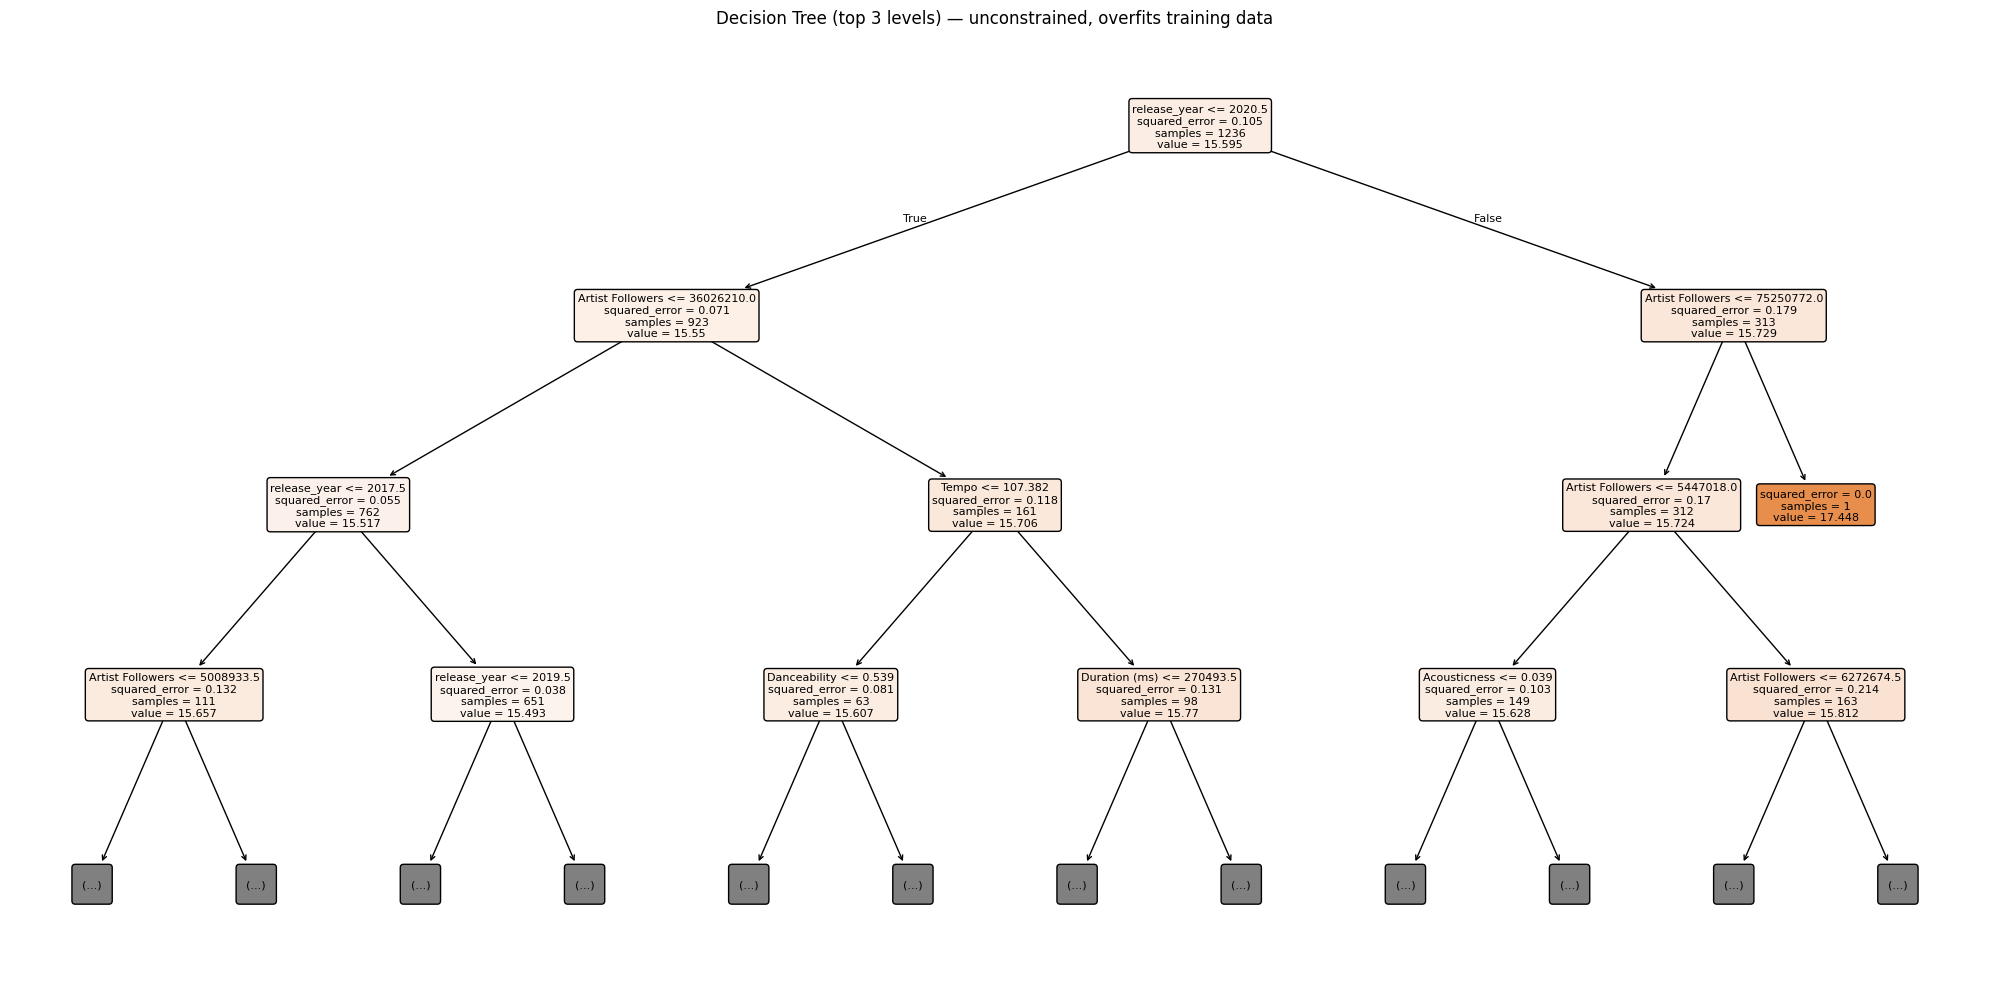

In [186]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt,                          # the unconstrained Decision Tree from earlier
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=3,                 # only show top 3 levels — full tree is unreadable
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree (top 3 levels) — unconstrained, overfits training data')
plt.tight_layout()
plt.show()

Constrained DT — Train RMSE: 0.2722
Constrained DT — Test RMSE:  0.2949


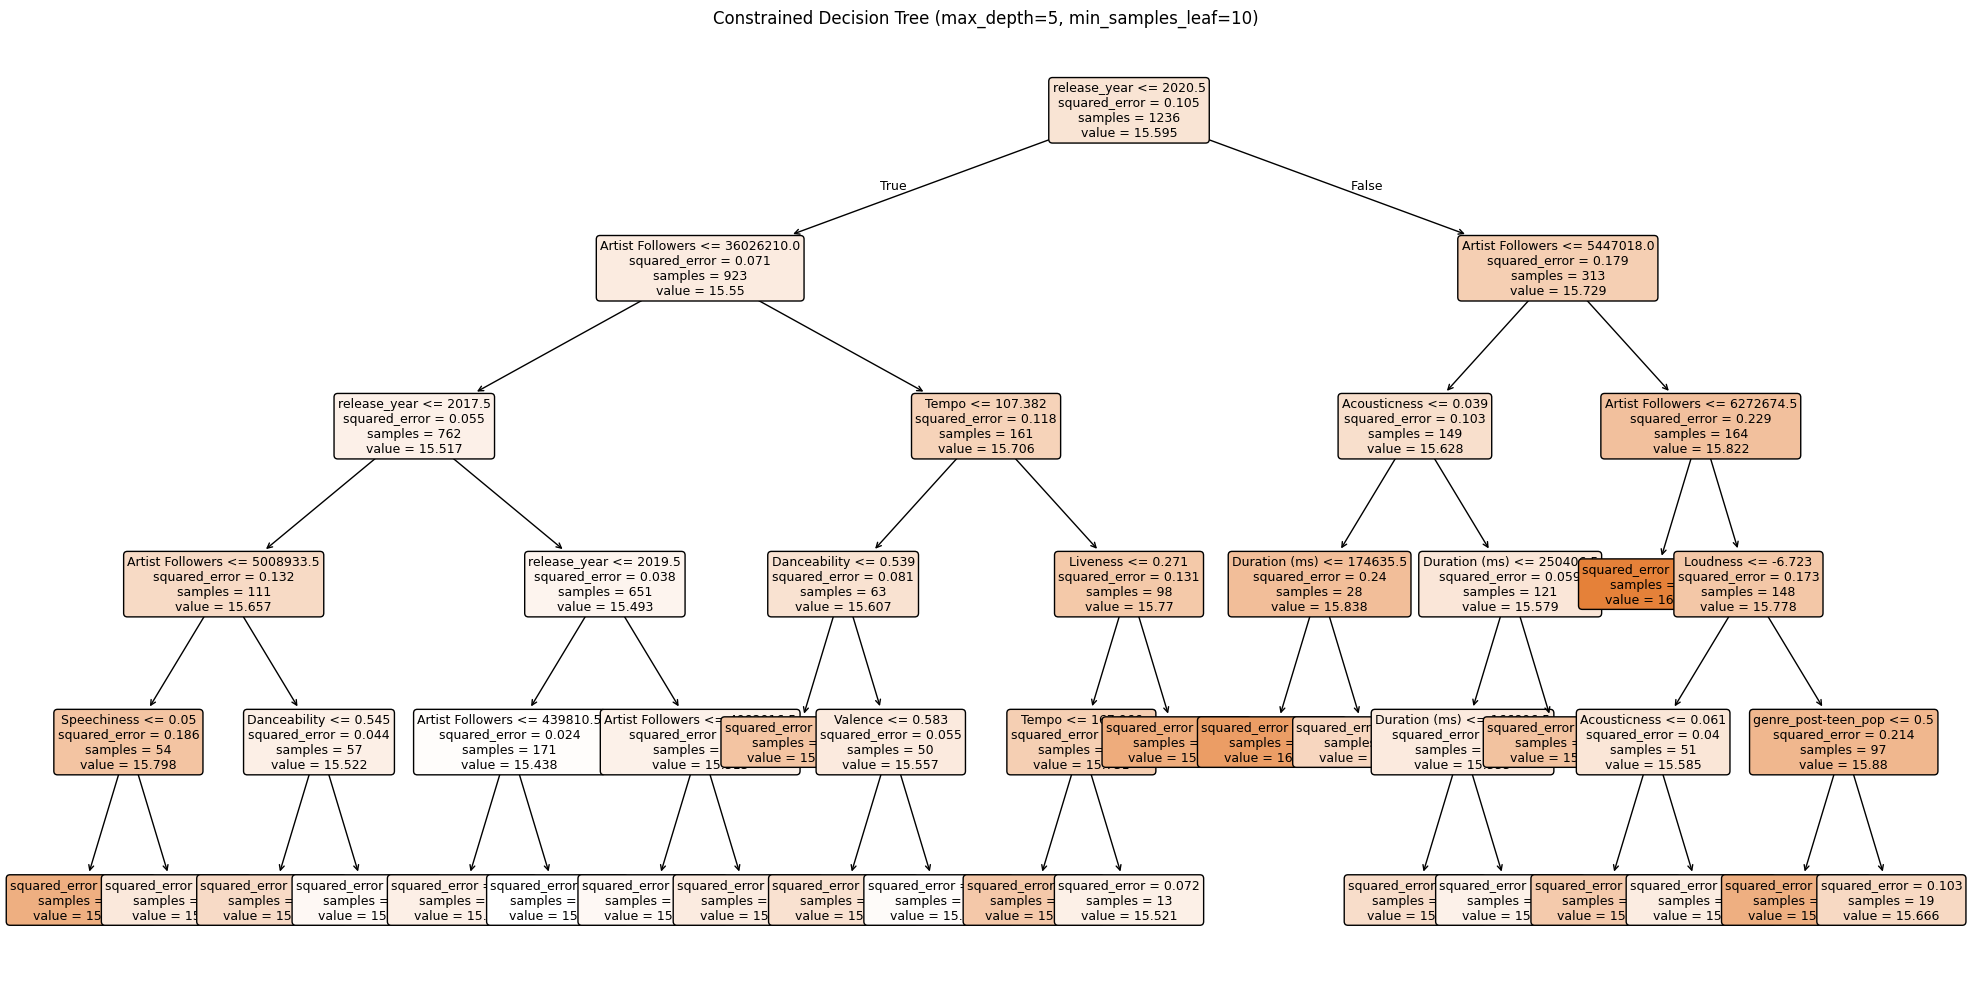

In [187]:
from sklearn.tree import DecisionTreeRegressor

# A constrained single tree, matching the discipline of the ensemble models
dt_constrained = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
dt_constrained.fit(X_train, y_train)

rmse_dtc_train = np.sqrt(mean_squared_error(y_train, dt_constrained.predict(X_train)))
rmse_dtc_test  = np.sqrt(mean_squared_error(y_test,  dt_constrained.predict(X_test)))
print(f"Constrained DT — Train RMSE: {rmse_dtc_train:.4f}")
print(f"Constrained DT — Test RMSE:  {rmse_dtc_test:.4f}")

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_constrained,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Constrained Decision Tree (max_depth=5, min_samples_leaf=10)')
plt.tight_layout()
plt.show()